In [1]:
import glob
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import resample
from scipy.signal import butter
from scipy.signal import filtfilt

In [2]:
# find files
path = r'D://Salzburg//TexSense//Messungen//IMU//treadmill_finki'
files = glob.glob(path + '//*.txt')
files.sort()

In [3]:
# slopes
slope = []
slope.extend(['level']*3)
slope.extend(['up_5']*3)
slope.extend(['up_10']*3)
slope.extend(['overground']*5)
slope = slope*3

# speeds
speed1 = ['8', '9', '10']
speed2 = ['7', '8', '9']
speed = []
speed.extend(speed1*3)
speed.extend(['self']*5)
speed.extend(speed2*3)
speed.extend(['self']*5)
speed.extend(speed2*3)
speed.extend(['self']*5)

# Surfaces
surface = []
surface.extend(['Treadmill']*9)
surface.extend(['Track']*5)
surface = surface*3

# Footwear
shoe = []
shoe.extend(['A']*14)
shoe.extend(['A']*14)
shoe.extend(['A']*14)

In [4]:
finki = pd.DataFrame({"Shoe": shoe,
             "Slope": slope,
             "Surface": surface,
             "Speed": speed,
             "Path": files})
finki

,Footwear,Slope,Surface,Speed,Path
0,A,level,Treadmill,8,D://Salzburg//TexSense//Messungen//IMU//treadm...
1,A,level,Treadmill,9,D://Salzburg//TexSense//Messungen//IMU//treadm...
2,A,level,Treadmill,10,D://Salzburg//TexSense//Messungen//IMU//treadm...
3,A,up_5,Treadmill,8,D://Salzburg//TexSense//Messungen//IMU//treadm...
4,A,up_5,Treadmill,9,D://Salzburg//TexSense//Messungen//IMU//treadm...
5,A,up_5,Treadmill,10,D://Salzburg//TexSense//Messungen//IMU//treadm...
6,A,up_10,Treadmill,8,D://Salzburg//TexSense//Messungen//IMU//treadm...
7,A,up_10,Treadmill,9,D://Salzburg//TexSense//Messungen//IMU//treadm...
8,A,up_10,Treadmill,10,D://Salzburg//TexSense//Messungen//IMU//treadm...
9,A,overground,Track,self,D://Salzburg//TexSense//Messungen//IMU//treadm...


In [5]:
def import_file(path):
    return pd.read_csv(path, sep='\t', header=1)

In [52]:
def IC_imu(df):
    r_racc = np.linalg.norm(df[df.columns[df.columns.str.contains(pat = 'R_Foot_ImuA')]], axis = 1)
    l_racc = np.linalg.norm(df[df.columns[df.columns.str.contains(pat = 'L_Foot_ImuA')]], axis = 1)
    
    #b, a = butter(4, 100/2000, btype='low')
    #r = filtfilt(b, a, right_foot_racc)
    #l = filtfilt(b, a, left_foot_racc)
    
    IC_right, _ = find_peaks(r_racc, distance = 500, height = 7)
    IC_left, _ = find_peaks(l_racc, distance = 500, height = 7)
    
    if r_racc.shape[0]-IC_right[-1]<1200:
        IC_right = IC_right[:-1]
    if l_racc.shape[0]-IC_left[-1]<1200:
        IC_left = IC_left[:-1]
    
    if len(IC_left) != len(IC_right):
        print('different steps left & right')
        if len(IC_right)<len(IC_left):
            IC_left=IC_left[:len(IC_right)]
        else:
            IC_right = IC_right[:len(IC_left)]
            
    return IC_right, IC_left

In [294]:
df = import_file(finki['Path'].iloc[33])

In [295]:
IC_r, IC_l = IC_imu(df)

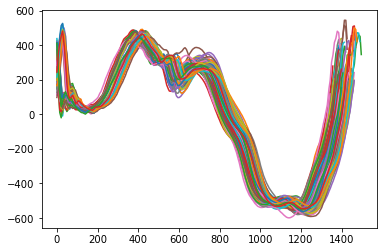

In [296]:
for i in range(len(IC_r)-1):
    plt.plot(df['L_Foot_Gyro :Y(D/s):'][IC_l[i]:IC_l[i+1]].values)

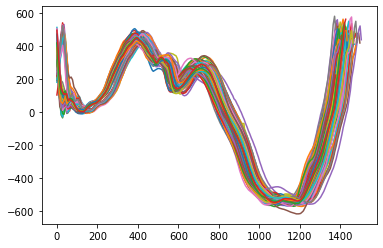

In [297]:
for i in range(len(IC_r)-1):
    plt.plot(df['R_Foot_Gyro :Y(D/s):'][IC_r[i]:IC_r[i+1]].values)

number of steps L: 82
number of steps R: 81


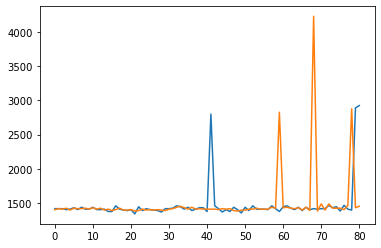

In [252]:
sig_r = np.linalg.norm(df[df.columns[df.columns.str.contains(pat = 'R_Foot_ImuA')]], axis = 1)
sig_l = np.linalg.norm(df[df.columns[df.columns.str.contains(pat = 'L_Foot_ImuA')]], axis = 1)
    
b, a = butter(4, 100/2000, btype='low')
#sig_r = filtfilt(b, a, sig_r)
#sig_l= filtfilt(b, a, sig_l)
    

IC_r, _ = find_peaks(sig_r, distance = 500, height = 7)
IC_l, _ = find_peaks(sig_l, distance = 500, height = 7)
print('number of steps L:', len(IC_l)-1)
print('number of steps R:', len(IC_r)-1)

l=[]
r=[]
for i in range(len(IC_r)-1):
    l.append(IC_l[i+1]-IC_l[i])
    r.append(IC_r[i+1]-IC_r[i])
#np.argmax(l)
plt.plot(l)
plt.plot(r)

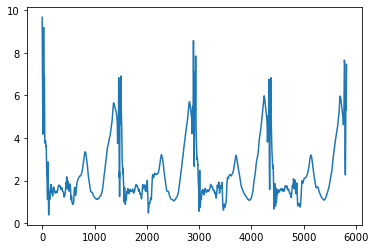

In [253]:
ex = np.argmax(l)
snip = sig_l[IC_l[ex-1]:IC_l[ex+1]]
#peak, _ = find_peaks(snip, distance = 1200, height = 40)
plt.plot(snip)
#plt.plot(snip, snip[IC[42:43]], 'x')

In [86]:
np.where(l>(np.mean(l) + 3*np.std(l)))[0][0]
np.where(l<(np.mean(l) - 3*np.std(l)))[0][0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
def ex_tolerance (IC):
    l=np.empty(len(IC)-1)
    for i in range(len(IC)-1):
        l=np.append(IC_l[i+1]-IC_l[i])
    l=np.array(l)
    up_tol = np.mean(l) + 3*np.std(l)
    np.where(l>up_tol)[0][0]

    return IC

In [114]:
l=[1,1,1,1,1,444,1,-444,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,444,1,1,1,1,1,1,1,1,1,1,-444]
l = np.array(l)
up_tol = np.mean(l) + 3*np.std(l)
low_to = np.mean(l) - 3*np.std(l)

In [130]:
np.delete(IC,[IC[np.where(l>up_tol)[0]]:IC[np.where(l>up_tol)[0]+1]])

SyntaxError: invalid syntax (790029955.py, line 1)

In [124]:
np.where(l>up_tol)[0]+1


array([ 6, 31], dtype=int64)

In [112]:
np.where(np.array(l)>up_tol)

(array([ 5, 30], dtype=int64),)

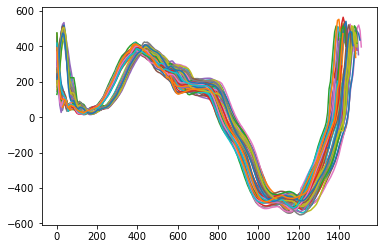

In [55]:
for i in range(len(IC_r)-1):
    plt.plot(df['L_Foot_Gyro :Y(D/s):'][IC_l[i]:IC_l[i+1]].values)

In [ ]:
for i in range(len(IC_r)-1):
    plt.plot(df['R_Foot_Gyro :Y(D/s):'][IC_r[i]:IC_r[i+1]].values)

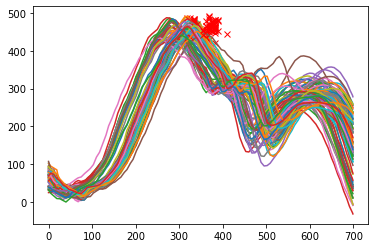

In [320]:
IC = IC_l
GyroY = df['L_Foot_Gyro :Y(D/s):']

TO=[]
sig = GyroY.values
for i in range(len(IC)-1):
    snip = sig[IC[i]+100:IC[i]+800] # search window + 400 ms
    peak, _ = find_peaks(snip, distance = 600, height = 200)
    TO.append(list(peak+IC[i]+100+48)) # add bias + 0.024 s
    plt.plot(snip)
    plt.plot(peak+48, snip[peak], 'x', c='r')
#snip = sig[IC[0]+100:IC[1]]



In [298]:
2000*.4

800.0

In [ ]:
#peak, _ = find_peaks(snip, distance = 300, height = 40)
#plt.plot(snip)
#plt.plot(peak, snip[peak], 'x')